In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("/content/train.csv", parse_dates=["date"])

In [3]:
print("Shape:", df.shape)

Shape: (913000, 4)


In [4]:
print(df.head())

        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14
3 2013-01-04      1     1     13
4 2013-01-05      1     1     10


In [5]:
print(df.describe())

                                date          store           item  \
count                         913000  913000.000000  913000.000000   
mean   2015-07-02 11:59:59.999999744       5.500000      25.500000   
min              2013-01-01 00:00:00       1.000000       1.000000   
25%              2014-04-02 00:00:00       3.000000      13.000000   
50%              2015-07-02 12:00:00       5.500000      25.500000   
75%              2016-10-01 00:00:00       8.000000      38.000000   
max              2017-12-31 00:00:00      10.000000      50.000000   
std                              NaN       2.872283      14.430878   

               sales  
count  913000.000000  
mean       52.250287  
min         0.000000  
25%        30.000000  
50%        47.000000  
75%        70.000000  
max       231.000000  
std        28.801144  


In [7]:
# Time-based features let a tree model pick up seasonality/trend
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)

# Lag features: yesterday's / last week's sales for this store-item
df = df.sort_values(["store", "item", "date"])
df["lag_1"] = df.groupby(["store", "item"])["sales"].shift(1)
df["lag_7"] = df.groupby(["store", "item"])["sales"].shift(7)
df["rolling_mean_7"] = (
    df.groupby(["store", "item"])["sales"]
    .transform(lambda s: s.shift(1).rolling(7).mean())
)

df = df.dropna()

In [8]:
features = ["store", "item", "year", "month", "day", "dayofweek",
            "weekofyear", "lag_1", "lag_7", "rolling_mean_7"]
target = "sales"

cutoff = df["date"].quantile(0.8)
train = df[df["date"] <= cutoff]
test = df[df["date"] > cutoff]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

In [10]:
model = RandomForestRegressor(
    n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"\nTest MAE:  {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")


Test MAE:  6.53
Test RMSE: 8.52



Saved feature_importance.png


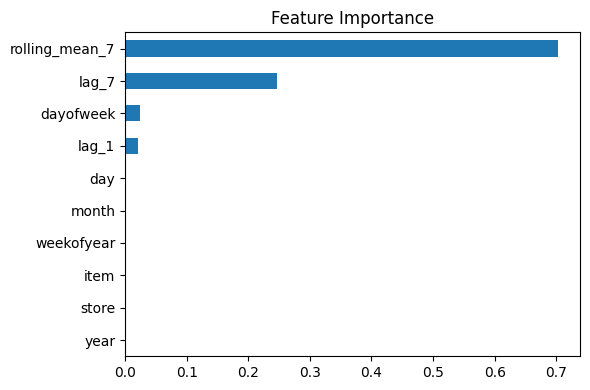

In [11]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", figsize=(6, 4), title="Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
print("\nSaved feature_importance.png")

In [12]:
test = test.copy()
test["predicted_sales"] = preds

In [13]:
demand_summary = (
    test.groupby(["store", "item"])["predicted_sales"]
    .agg(avg_daily_demand="mean", std_daily_demand="std")
    .reset_index()
)
demand_summary.to_csv("demand_forecast_summary.csv", index=False)
print("\nSaved demand_forecast_summary.csv — this feeds Day 2's optimizer")
print(demand_summary.head())


Saved demand_forecast_summary.csv — this feeds Day 2's optimizer
   store  item  avg_daily_demand  std_daily_demand
0      1     1         22.493453          5.231010
1      1     2         59.955269         14.157695
2      1     3         37.683349          8.844934
3      1     4         22.444548          5.118532
4      1     5         19.182469          4.139651
